# 앙상블 학습 ① Voting · Bagging · Random Forest

**핵심 질문**: 여러 모델을 합치면 왜 더 좋아지는가?

**오늘의 목표**
1. **Bias vs Variance**: 과소적합/과적합의 근본 원인과 트레이드오프
2. **Voting**: 서로 다른 모델의 다수결(Hard) / 확률 평균(Soft)
3. **Bagging**: 같은 모델 + 부트스트랩 → Variance(분산) 감소
4. **Random Forest**: Bagging + 특성 무작위화 → 트리 간 상관↓ → 분산 더 감소
5. **Feature Importance**: Impurity 기반 vs **Permutation** 기반 중요도 비교
6. **GridSearchCV**: n_estimators, max_depth, max_features 최적 조합 탐색

**예제**: Wine 데이터 (Voting/Bagging/RF 성능 비교, Feature Importance, GridSearchCV 튜닝)

---
## 결정 트리 복습 → 앙상블로의 전환

결정 트리의 장점과 한계를 배움:

| 장점 | 한계 |
|------|------|
| 사람이 규칙을 읽을 수 있음 | 깊이 제한 없으면 과적합 (Train=1.0, Test↓) |
| Feature Importance 자동 제공 | 데이터가 조금만 바뀌어도 트리 구조가 크게 달라짐 |
| 스케일링 불필요 | 단일 트리의 **Variance(분산)가 높음** |

> 결정 트리의 가장 큰 약점: **불안정함(Variance↑)**  
> 같은 데이터에서 샘플을 조금만 바꿔도 완전히 다른 트리가 만들어짐

### 앙상블의 핵심 아이디어

> **"혼자보다 여럿이 낫다"**  
> 불안정한 모델(높은 분산)을 여러 개 합치면 → 평균 효과로 안정화  
> 이것이 바로 **앙상블 학습(Ensemble Learning)**의 출발점!

## 먼저 체감해보자 — 트리는 왜 불안정할까?

단일 트리는 데이터가 조금만 바뀌어도 경계가 크게 흔들림
앙상블은 이 ‘흔들림’을 줄이는 설계임

In [1]:
# Bagging — 2D 결정 경계 시각화 (Plotly 버전)
import numpy as np
import plotly.graph_objects as go
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

np.random.seed(42)

X2, y2 = make_classification(n_samples=500, n_features=2, n_redundant=0, n_informative=2,
                             n_clusters_per_class=1, class_sep=1.0, random_state=42)

tree_single = DecisionTreeClassifier(max_depth=None, random_state=42).fit(X2, y2)
bagging = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=None,
                                                             random_state=42),
                                                            n_estimators=100, # 모델 수, 많으면 많을수록 안정성 확보
                                                            max_samples=0.8, # 부트스트랩 샘플 크기
                                                            bootstrap=True,
                                                           random_state=42).fit(X2, y2)

pad = 1.0
xx, yy = np.meshgrid(
    np.linspace(X2[:, 0].min() - pad, X2[:, 0].max() + pad, 400),
    np.linspace(X2[:, 1].min() - pad, X2[:, 1].max() + pad, 400)
)
grid = np.c_[xx.ravel(), yy.ravel()]

Z_single = tree_single.predict(grid).reshape(xx.shape)
Z_bag = bagging.predict(grid).reshape(xx.shape)


def plot_boundary_plotly(xx, yy, Z, X, y, title):
    fig = go.Figure()

    fig.add_trace(go.Contour(
        x=xx[0], y=yy[:, 0], z=Z,
        showscale=False, opacity=0.3,
        contours_coloring="heatmap",
        name="decision boundary"
    ))

    fig.add_trace(go.Scatter(
        x=X[:, 0], y=X[:, 1], mode="markers",
        marker=dict(size=8, color=y, colorscale="Viridis", line=dict(width=1, color="black")),
        name="data"
    ))

    fig.update_layout(
        title=title,
        xaxis_title="Feature 1",
        yaxis_title="Feature 2",
        template="plotly_dark",
        width=600, height=500
    )
    fig.show()


# 실행
plot_boundary_plotly(xx, yy, Z_single, X2, y2, "Decision Tree (과적합 경향)")
plot_boundary_plotly(xx, yy, Z_bag, X2, y2, "Bagging (분산 감소·일반화 경향)")

# 앙상블 학습(Ensemble Learning)
- 정의: 2인 이상의 연주, 전체적인 어울림 또는 함께, 동시에란 뜻
- 핵심:
  - **Voting**: 서로 다른 모델의 합주(다수결/확률 평균) → 극단 예측 완화
  - **Bagging**: 같은 모델 여러 개 평균(부트스트랩) → **Variance(분산)** 감소
    - **Random Forest**: Bagging + **특성 무작위화** → 트리 간 상관↓ → 평균 효과↑
  - **Boosting**: 앞 모델(학습)의 실수를 뒤 모델이 보완(순차 학습) → **Bias(편향)** ↓ → 정확성↑



- 앙상블 세가지
    - Voting: 서로 다른 모델을 투표로 합침(다양성 필요)
	- Bagging: 같은 모델을 부트스트랩으로 여러 개 만들어 평균(Variance↓)
    - Boosting: 실수를 기억하며 순차 보정(Bias↓) — Part2

### 앙상블 다양성 (Diversity)
![앙상블 다양성 (Diversity)](앙상블_다양성_Diversity.png)

### 앙상블 독립성 (Independence)
![앙상블 독립성 (Independence)](앙상블_독립성_Independence.png)

### 목표
1) Voting/Bagging 차이를 한 문장으로 설명
2) 왜 Soft Voting이 더 안정적
3) 혼동행렬(정규화)·CV mean±std로 모델을 해석

### 요약
- 여러 모델의 집단 지성 → 더 안정적이고 강력한 예측
- Bagging → Variance(분산) ↓ (안정성↑) - 같은 모델 동시에 학습(병렬)
- Boosting → Bias(편향) ↓ (정확성↑) - 앞 모델(학습)의 실수를 뒤에 보완(순차 학습)
- Voting → 앙상블의 출발점 (가장 단순한 방식)

## 1) Bias vs Variance

- **Bias (편향)**: 모델이 너무 단순하여 데이터의 중요한 패턴을 학습하지 못함 → 과소적합
- **Variance (분산)**: 모델이 너무 복잡하여 학습 데이터에 과도하게 적합 → 과적합
- 두 값은 trade-off 관계, 적절한 균형점을 찾는 것이 중요
- ※ 주의: Bias는 단순 모델뿐 아니라 **잘못된 가정/누락 피처/레이블 오류**에서도 발생할 수 있음

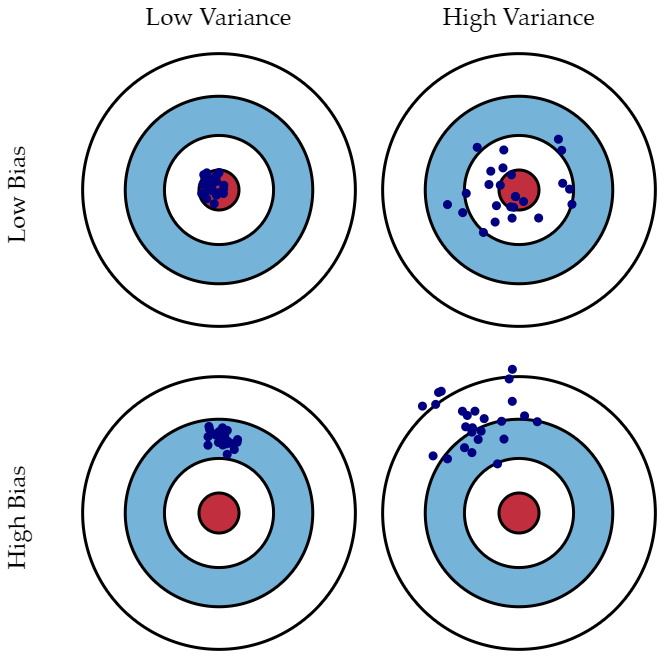
- 출처: http://scott.fortmann-roe.com

Bias vs Variance 곡선 시각화


In [2]:
import numpy as np
import plotly.graph_objects as go

complexity = np.linspace(0, 10, 100)

bias2 = (10 - complexity) ** 2 / 10
variance = (complexity) ** 2 / 10
error = bias2 + variance

fig = go.Figure()
fig.add_trace(go.Scatter(x=complexity, y=bias2, mode="lines", name="Bias² (편향 제곱)", line=dict(color="cyan", width=3)))
fig.add_trace(
    go.Scatter(x=complexity, y=variance, mode="lines", name="Variance (분산)", line=dict(color="magenta", width=3)))
fig.add_trace(go.Scatter(x=complexity, y=error, mode="lines", name="Total Error (총 오차)",
                         line=dict(color="yellow", width=3, dash="dot")))
fig.add_vline(x=5, line=dict(color="green", width=2, dash="dash"), annotation_text="균형점",
              annotation_position="top right")
fig.update_layout(title="Bias vs Variance Trade-off", xaxis_title="모델 복잡도", yaxis_title="오차 (Error)",
                  template="plotly_dark")
fig.show()

![image.png](attachment:bc201e7e-7fda-4b3c-a016-6837e3b17442.png)
- 출처: http://scott.fortmann-roe.com

| **구분**               | **Bias** | **Variance** | **상태** | **예시**      |
| -------------------- | -------- | ------------ | ------ | ----------- |
| Low Bias · Low Var   | ↓        | ↓            | 이상적    | 중심 근처에 모인 점 |
| Low Bias · High Var  | ↓        | ↑            | 과적합    | 중심 주변 흩어짐   |
| High Bias · Low Var  | ↑        | ↓            | 과소적합   | 한쪽에 몰림      |
| High Bias · High Var | ↑        | ↑            | 최악     | 멀리 흩어짐      |

### 잔차(Residual)

- 잔차 = 실제값 - 예측값
- 틀린거: 이거 줄이자

### Boosting 순차적 보정
![Boosting 순차적 보정](Boosting_순차적보정.png)

### 오차(Residual)에 집중
![오차(Residual)에 집중](오차_Residual_집중.png)

Bias 높으면 -> 과소적합 -> 너무 단순
Variance 높으면 -> 과적합 -> 너무 복잡

앙상블 -> 이 둘의 균형을 잡는 대표적인 방법 중 하나
- **Bagging** -> Variance를 줄이자: 모델 안정화
    - 모델을 여러개 만들어서 흔들림(분산)을 줄이는거
- **Boosting** -> Bais를 줄이자: 예측 정밀화
    - 잔차를 줄여서 **정확도 개선**

## 2) Voting (투표 기반 앙상블)

여러 모델의 예측을 **투표**로 결합하는 방법입니다.
- **Hard Voting**: 라벨 다수결
- **Soft Voting**: 예측 **확률** 평균
    - → 확신도까지 반영되어 **대체로** 더 안정적
- ※ Soft가 항상 우월한 건 아님(확률 품질이 낮은 모델이 섞이면 예외). 필요 시 **가중 투표** 또는 **확률 보정(CalibratedClassifierCV)**.

### Hard Voting vs Soft Voting
![Hard Voting vs Soft Voting](Hard_vs_Soft_Voting.png)

## 요약
1. 약점 보완: 특정 모델의 실수를 다른 모델이 보완
2. 안정성 향상: 여러 모델의 평균 -> 우연의 오차 상쇄
3. 직관적 구조: 쉬워여. 앙상블이 이런거구나 알 수 있는거다 말씀을 드릴 있습니다.

### Soft Voting의 함정 - 확률 품질
![Soft Voting의 함정 - 확률 품질](Soft_Voting_확률품질.png)

### 신뢰도 보정 전략
![신뢰도 보정 전략](신뢰도_보정_전략.png)

## Wine

In [3]:
import numpy as np, pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

wine = load_wine()
X, y = wine.data, wine.target
feature_names = wine.feature_names
target_names = wine.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("X shape:", X.shape)
print("class distribution:", np.bincount(y))

X shape: (178, 13)
class distribution: [59 71 48]


In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

log_clf = Pipeline([("scaler", StandardScaler()),
                    ("clf", LogisticRegression(max_iter=5000, random_state=42))])

knn_clf = Pipeline([("scaler", StandardScaler()),
                    ("clf", KNeighborsClassifier(n_neighbors=7))])

dt_clf = DecisionTreeClassifier(max_depth=4, random_state=42)

In [5]:
from sklearn.ensemble import VotingClassifier

voting_hard = VotingClassifier(
    estimators=[("lr", log_clf), ("knn", knn_clf), ("dt", dt_clf)],
    voting="hard"
)

voting_soft = VotingClassifier(
    estimators=[("lr", log_clf), ("knn", knn_clf), ("dt", dt_clf)],
    # 확률 평균
    voting="soft"
)

# 가중 투표
# voting_soft_w = VotingClassifier(
#     estimators=[("lr", log_clf), ("knn", knn_clf), ("dt", dt_clf)],
#     voting="soft",
#     weights=[2, 1, 1]
# )

In [6]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import plotly.figure_factory as ff
import plotly.express as px

models = {
    "Logistic": log_clf,
    "KNN": knn_clf,
    "DecisionTree": dt_clf,
    "Voting(Hard)": voting_hard,
    "Voting(Soft)": voting_soft
}

results = []
reports = {}

for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append([name, acc])
    reports[name] = classification_report(y_test, y_pred, target_names=target_names, digits=3, output_dict=True)
    print(f"\n== {name} ==")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred, target_names=target_names, digits=3))

    cm = confusion_matrix(y_test, y_pred)
    fig = ff.create_annotated_heatmap(z=cm, x=list(target_names), y=list(target_names),
                                      colorscale="Blues", showscale=True)
    fig.update_layout(title=f"Confusion Matrix — {name} (Counts)",
                      xaxis_title="Predicted", yaxis_title="Actual",
                      template="plotly_dark")
    fig.show()

    cm_norm = confusion_matrix(y_test, y_pred, normalize="true")
    fig2 = ff.create_annotated_heatmap(z=np.round(cm_norm, 3), x=list(target_names), y=list(target_names),
                                       colorscale="Blues", showscale=True)
    fig2.update_layout(title=f"Confusion Matrix — {name} (Normalized by True)",
                       xaxis_title="Predicted", yaxis_title="Actual",
                       template="plotly_dark")
    fig2.show()

df_results = pd.DataFrame(results, columns=["Model", "Test Accuracy"]).sort_values("Test Accuracy", ascending=False)
fig_bar = px.bar(df_results, x="Model", y="Test Accuracy",
                 title="Model Accuracy Comparison (Wine)",
                 template="plotly_dark", text="Test Accuracy")
fig_bar.update_traces(texttemplate="%{text:.3f}", textposition="outside")
fig_bar.update_layout(yaxis=dict(range=[0, 1]))
fig_bar.show()

df_results


== Logistic ==
Accuracy: 0.9722222222222222
              precision    recall  f1-score   support

     class_0      1.000     1.000     1.000        12
     class_1      0.933     1.000     0.966        14
     class_2      1.000     0.900     0.947        10

    accuracy                          0.972        36
   macro avg      0.978     0.967     0.971        36
weighted avg      0.974     0.972     0.972        36




== KNN ==
Accuracy: 1.0
              precision    recall  f1-score   support

     class_0      1.000     1.000     1.000        12
     class_1      1.000     1.000     1.000        14
     class_2      1.000     1.000     1.000        10

    accuracy                          1.000        36
   macro avg      1.000     1.000     1.000        36
weighted avg      1.000     1.000     1.000        36




== DecisionTree ==
Accuracy: 0.9444444444444444
              precision    recall  f1-score   support

     class_0      1.000     0.917     0.957        12
     class_1      0.875     1.000     0.933        14
     class_2      1.000     0.900     0.947        10

    accuracy                          0.944        36
   macro avg      0.958     0.939     0.946        36
weighted avg      0.951     0.944     0.945        36




== Voting(Hard) ==
Accuracy: 0.9722222222222222
              precision    recall  f1-score   support

     class_0      1.000     1.000     1.000        12
     class_1      0.933     1.000     0.966        14
     class_2      1.000     0.900     0.947        10

    accuracy                          0.972        36
   macro avg      0.978     0.967     0.971        36
weighted avg      0.974     0.972     0.972        36




== Voting(Soft) ==
Accuracy: 0.9722222222222222
              precision    recall  f1-score   support

     class_0      1.000     1.000     1.000        12
     class_1      0.933     1.000     0.966        14
     class_2      1.000     0.900     0.947        10

    accuracy                          0.972        36
   macro avg      0.978     0.967     0.971        36
weighted avg      0.974     0.972     0.972        36



,Model,Test Accuracy
1,KNN,1.000000
0,Logistic,0.972222
3,Voting(Hard),0.972222
4,Voting(Soft),0.972222
2,DecisionTree,0.944444


In [7]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import plotly.graph_objects as go

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_data = wine.data
y = wine.target

cv_rows = []
for name, clf in models.items():
    scores = cross_val_score(clf, X_data, y, cv=cv, scoring="accuracy", n_jobs=-1)
    cv_rows.append([name, scores.mean(), scores.std()])

cv_df = pd.DataFrame(cv_rows, columns=["Model", "CV mean acc", "CV std"]).sort_values("CV mean acc", ascending=False)
display(cv_df)

x_models = cv_df["Model"]
y_cv = cv_df["CV mean acc"].values
e_cv = cv_df["CV std"].values

fig_cv = go.Figure()
fig_cv.add_trace(go.Scatter(x=x_models, y=y_cv, mode="markers+lines", name="CV mean acc"))
fig_cv.add_trace(go.Scatter(
    x=list(x_models) + list(x_models[::-1]),
    y=list(y_cv + e_cv) + list((y_cv - e_cv)[::-1]),
    fill="toself", opacity=0.2, name="±1 std"
))
fig_cv.update_layout(title="Cross-Validation Accuracy (mean ± std)",
                     xaxis_title="Model", yaxis_title="CV Accuracy",
                     template="plotly_dark", yaxis=dict(range=[0, 1]))
fig_cv.show()

,Model,CV mean acc,CV std
0,Logistic,0.983333,0.013608
3,Voting(Hard),0.977460,0.027610
1,KNN,0.971905,0.025206
4,Voting(Soft),0.971905,0.025206
2,DecisionTree,0.882063,0.037655


## 3) Bagging (Bootstrap Aggregating)

- 동일한 모델을 **서로 다른 부트스트랩 샘플**로 여러 개 학습 → 평균/다수결
    - 서로 다른 데이터 셋을 기반으로 제각각 학습
- **Variance(분산)**을 줄여 과적합을 완화
- 주로 Decision Tree와 함께 사용
- OOB 점수로 검증셋 없이도 대략 성능 추정 가능

### OOB의 탄생 - Bagging Process
![OOB의 탄생 - Bagging Process](OOB_탄생_Bagging.png)

### OOB 평가 프로세스
![OOB 평가 프로세스](OOB_평가_프로세스.png)

In [9]:
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report

bag_wine = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=None, random_state=42),
                             n_estimators=100,
                             max_samples=0.8,
                             bootstrap=True,
                             oob_score=True,
                             random_state=42)
bag_wine.fit(X_train, y_train)
pred_bag = bag_wine.predict(X_test)
print("Bagging Test Acc:", accuracy_score(y_test, pred_bag))
print("OOB Score:", bag_wine.oob_score_)
print(classification_report(y_test, pred_bag, target_names=target_names, digits=3))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
base = DecisionTreeClassifier(max_depth=None, random_state=42)
scores_base = cross_val_score(base, wine.data, wine.target, cv=cv, scoring="accuracy", n_jobs=-1)
scores_bag = cross_val_score(bag_wine, wine.data, wine.target, cv=cv, scoring="accuracy", n_jobs=-1)
print(f"Single Tree          CV mean±std: {scores_base.mean():.3f} ± {scores_base.std():.3f}")
print(f"Bagging(Tree×100)    CV mean±std: {scores_bag.mean():.3f} ± {scores_bag.std():.3f}")

Bagging Test Acc: 1.0
OOB Score: 0.9507042253521126
              precision    recall  f1-score   support

     class_0      1.000     1.000     1.000        12
     class_1      1.000     1.000     1.000        14
     class_2      1.000     1.000     1.000        10

    accuracy                          1.000        36
   macro avg      1.000     1.000     1.000        36
weighted avg      1.000     1.000     1.000        36

Single Tree          CV mean±std: 0.893 ± 0.038
Bagging(Tree×100)    CV mean±std: 0.966 ± 0.033


## 정리
- OOB 점수: 부트스트랩에서 적용 안된 샘플을 기반으로 내부 검증 -> 검증셋(test set)없이 대략적으로 성능 가능
- CV평균, 표준편차: 성능(평균), 안정성(표준편차)를 같이 보아야 함
- 혼동행렬도 같이 보면 좋음

## Random Forest

###  개념
- **Random Forest = Bagging(트리 × N) + 특성 무작위화(`max_features`)**
- 목적: 트리끼리 **덜 닮게(correlation ↓)** 만들어 평균했을 때 **분산(Variance)을 더 강하게 ↓**
- 결과: 단일 트리의 **과적합(분산↑)**을 억제 → Bagging보다 **더 안정적이고 일반화 성능↑**

### Random Forest 병렬적 다양성
![Random Forest 병렬적 다양성](Random_Forest_병렬적다양성.png)

### Bootstrap과 Feature Randomness
![Bootstrap과 Feature Randomness](Bootstrap_Feature_Randomness.png)


### 왜 `max_features`(특성 무작위화)가 필요한가?
- Bagging만 쓰면 **강력한 피처** 때문에 모든 트리가 비슷한 규칙으로 시작 → **복사본 평균** 효과
- RF는 **분기마다 고려 피처를 무작위로 제한** → 트리 간 관점 다양성↑ → **상관↓** → 평균 시 실수 상쇄 → **분산 ↓**


### 핵심 하이퍼파라미터
| 항목 | 설명 | WHY |
|---|---|---|
| `n_estimators` | 트리 개수(100~300+ 권장) | 많을수록 평균 효과↑, 분산↓ (시간·메모리 비용은 ↑) |
| `max_features` | 분기마다 고려 피처 수 | 작을수록 다양성↑, 상관↓ → RF 핵심 (너무 작으면 정보 손실) |
| `max_depth`/`min_samples_leaf` | 트리 복잡도 제어 | 깊으면 과적합↑, 적절 제한 → 일반화↑ |
| `oob_score=True` | Out-of-Bag 내장 검증 | 부트스트랩에서 빠진 샘플(≈36.8%)로 훈련 내부 성능 추정 |
| `n_jobs=-1` | 병렬 학습 | 모든 코어 사용 → 속도↑ |

> OOB vs CV: **성격이 다름**. 같은 축으로 비교하지 말고 **둘 다 참고**, 최종 평가는 **Test**에서.

### Bias–Variance
- 단일 트리: Variance ↑(불안정) → 과적합 위험
- Bagging: Variance ↓(평균 효과)
- Random Forest: Variance **↓↓**(트리 간 상관까지 낮춤)

### Random Forest Variance 감소
![Random Forest Variance 감소](Random_Forest_Variance_감소.png)

###  Single Tree vs Bagging (분산 감소)
**목표:** Bagging을 하면 결정 경계가 **덜 요동치고(분산↓)** 일반화가 좋아지는 걸 눈으로 확인

In [10]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine, make_classification
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.inspection import permutation_importance
import plotly.figure_factory as ff
import plotly.express as px
import plotly.graph_objects as go

In [11]:
X2, y2 = make_classification(
    n_samples=500, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, class_sep=1.0, random_state=42
)

tree_single = DecisionTreeClassifier(max_depth=None, random_state=42).fit(X2, y2)

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=None),
    n_estimators=100, max_samples=0.8, bootstrap=True,
    n_jobs=-1, random_state=42
).fit(X2, y2)

xx, yy = np.meshgrid(
    np.linspace(X2[:, 0].min() - 1, X2[:, 0].max() + 1, 300),
    np.linspace(X2[:, 1].min() - 1, X2[:, 1].max() + 1, 300)
)
grid = np.c_[xx.ravel(), yy.ravel()]
Z_single = tree_single.predict(grid).reshape(xx.shape)
Z_bag = bagging.predict(grid).reshape(xx.shape)

fig1 = go.Figure(data=[go.Contour(x=xx[0], y=yy[:, 0], z=Z_single, showscale=False, opacity=0.3)])
fig1.add_scatter(x=X2[:, 0], y=X2[:, 1], mode="markers",
                 marker=dict(size=6, color=y2), showlegend=False)
fig1.update_layout(title="Decision Boundary — Single Tree (과적합 경향)",
                   template="plotly_dark", xaxis_title="x1", yaxis_title="x2")
fig1.show()

fig2 = go.Figure(data=[go.Contour(x=xx[0], y=yy[:, 0], z=Z_bag, showscale=False, opacity=0.3)])
fig2.add_scatter(x=X2[:, 0], y=X2[:, 1], mode="markers",
                 marker=dict(size=6, color=y2), showlegend=False)
fig2.update_layout(title="Decision Boundary — Bagging (분산 감소·일반화 경향)",

                   template="plotly_dark", xaxis_title="x1", yaxis_title="x2")

fig2.show()


In [12]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score

X_tr, X_te, y_tr, y_te = train_test_split(X2, y2, test_size=0.3, stratify=y2, random_state=42)

tree_single = DecisionTreeClassifier(max_depth=None, random_state=42).fit(X_tr, y_tr)
bagging = BaggingClassifier(DecisionTreeClassifier(max_depth=None),
                            n_estimators=100, max_samples=0.8, bootstrap=True,
                            n_jobs=-1, random_state=42).fit(X_tr, y_tr)

print("Single Tree  Test Acc:", accuracy_score(y_te, tree_single.predict(X_te)))

print("Bagging      Test Acc:", accuracy_score(y_te, bagging.predict(X_te)))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tree_cv = cross_val_score(DecisionTreeClassifier(max_depth=None, random_state=42),
                          X2, y2, cv=cv, scoring="accuracy", n_jobs=-1)
bag_cv = cross_val_score(BaggingClassifier(DecisionTreeClassifier(max_depth=None),
                                           n_estimators=100, max_samples=0.8, bootstrap=True, n_jobs=-1,
                                           random_state=42),
                         X2, y2, cv=cv, scoring="accuracy", n_jobs=-1)
print(f"Single Tree  CV mean±std: {tree_cv.mean():.3f} ± {tree_cv.std():.3f}")
print(f"Bagging      CV mean±std: {bag_cv.mean():.3f} ± {bag_cv.std():.3f}")

Single Tree  Test Acc: 0.94
Bagging      Test Acc: 0.9666666666666667
Single Tree  CV mean±std: 0.944 ± 0.022
Bagging      CV mean±std: 0.952 ± 0.021


### Wine 데이터: Single Tree vs Bagging vs Random Forest
**목표:** Test 정확도, OOB 점수, 정규화 혼동행렬, 교차검증 평균±표준편차로 **성능+안정성**을 수치로 비교

In [13]:
wine = load_wine()
X, y = wine.data, wine.target
target_names = wine.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

tree_single = DecisionTreeClassifier(max_depth=None, random_state=42)
tree_single.fit(X_train, y_train)
pred_single = tree_single.predict(X_test)
acc_single = accuracy_score(y_test, pred_single)

bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=None),
    n_estimators=100, max_samples=0.8, bootstrap=True,
    oob_score=True, n_jobs=-1, random_state=42
)
bag.fit(X_train, y_train)
pred_bag = bag.predict(X_test)
acc_bag = accuracy_score(y_test, pred_bag)
oob_bag = bag.oob_score_

rf = RandomForestClassifier(
    n_estimators=300, max_features="sqrt",
    bootstrap=True, oob_score=True, n_jobs=-1, random_state=42
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, pred_rf)
oob_rf = rf.oob_score_

display(pd.DataFrame({
    "Model": ["Single Tree", "Bagging(Tree×100)", "RandomForest(Tree×300)"],
    "Test Accuracy": [acc_single, acc_bag, acc_rf],
    "OOB (if available)": [np.nan, oob_bag, oob_rf]
}))

print("\n== Single Tree ==")
print(classification_report(y_test, pred_single, target_names=target_names, digits=3))
print("\n== Bagging (Tree×100) ==")
print("OOB Score:", oob_bag)
print(classification_report(y_test, pred_bag, target_names=target_names, digits=3))
print("\n== Random Forest (Tree×300) ==")
print("OOB Score:", oob_rf)
print(classification_report(y_test, pred_rf, target_names=target_names, digits=3))


def show_cm(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, normalize="true")
    fig = ff.create_annotated_heatmap(
        z=np.round(cm, 3), x=list(target_names), y=list(target_names),
        colorscale="Blues", showscale=True
    )
    fig.update_layout(title=f"Confusion Matrix (Normalized) — {name}",
                      xaxis_title="Predicted", yaxis_title="Actual",
                      template="plotly_dark")
    fig.show()


show_cm("Single Tree", y_test, pred_single)
show_cm("Bagging", y_test, pred_bag)
show_cm("RandomForest", y_test, pred_rf)

df_acc = pd.DataFrame({"Model": ["Single Tree", "Bagging(Tree×100)", "RandomForest(Tree×300)"],
                       "Test Accuracy": [acc_single, acc_bag, acc_rf]})
fig_bar = px.bar(df_acc, x="Model", y="Test Accuracy",
                 title="Wine — Test Accuracy", template="plotly_dark",
                 text="Test Accuracy")
fig_bar.update_traces(texttemplate="%{text:.3f}", textposition="outside")
fig_bar.update_layout(yaxis=dict(range=[0, 1]))
fig_bar.show()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_single = cross_val_score(tree_single, X, y, cv=cv, scoring="accuracy", n_jobs=-1)
scores_bag = cross_val_score(bag, X, y, cv=cv, scoring="accuracy", n_jobs=-1)
scores_rf = cross_val_score(rf, X, y, cv=cv, scoring="accuracy", n_jobs=-1)

cv_df = pd.DataFrame({
    "Model": ["Single Tree", "Bagging(Tree×100)", "RandomForest(Tree×300)"],
    "CV mean acc": [scores_single.mean(), scores_bag.mean(), scores_rf.mean()],
    "CV std": [scores_single.std(), scores_bag.std(), scores_rf.std()]
}).sort_values("CV mean acc", ascending=False)
display(cv_df)

x = cv_df["Model"]
y = cv_df["CV mean acc"].values
e = cv_df["CV std"].values

fig_cv = go.Figure()
fig_cv.add_trace(go.Scatter(x=x, y=y, mode="markers+lines", name="CV mean acc"))
fig_cv.add_trace(go.Scatter(
    x=list(x) + list(x[::-1]),
    y=list(y + e) + list((y - e)[::-1]),
    fill="toself", opacity=0.2, name="±1 std"
))
fig_cv.update_layout(title="Wine — Cross-Validation Accuracy (mean ± std)",
                     xaxis_title="Model", yaxis_title="CV Accuracy",
                     template="plotly_dark", yaxis=dict(range=[0, 1]))
fig_cv.show()


,Model,Test Accuracy,OOB (if available)
0,Single Tree,0.944444,NaN
1,Bagging(Tree×100),1.000000,0.950704
2,RandomForest(Tree×300),1.000000,0.978873



== Single Tree ==
              precision    recall  f1-score   support

     class_0      1.000     0.917     0.957        12
     class_1      0.875     1.000     0.933        14
     class_2      1.000     0.900     0.947        10

    accuracy                          0.944        36
   macro avg      0.958     0.939     0.946        36
weighted avg      0.951     0.944     0.945        36


== Bagging (Tree×100) ==
OOB Score: 0.9507042253521126
              precision    recall  f1-score   support

     class_0      1.000     1.000     1.000        12
     class_1      1.000     1.000     1.000        14
     class_2      1.000     1.000     1.000        10

    accuracy                          1.000        36
   macro avg      1.000     1.000     1.000        36
weighted avg      1.000     1.000     1.000        36


== Random Forest (Tree×300) ==
OOB Score: 0.9788732394366197
              precision    recall  f1-score   support

     class_0      1.000     1.000     1.000   

,Model,CV mean acc,CV std
2,RandomForest(Tree×300),0.983016,0.022780
1,Bagging(Tree×100),0.966190,0.033135
0,Single Tree,0.893175,0.038028


### Feature Importance — Impurity vs Permutation
- **Impurity 기반** 중요도: 분할을 많이 일으킨/연속 피처에 편향 가능
- **Permutation** 중요도: 예측 성능 변화(Δaccuracy) 기반 → **해석 친화**(느리지만 신뢰↑)

> Importance는 '원인'이 아니라 힌트
>
> 모델이 사용한 흔적을 보여줄 뿐, 인과관계를 의미하지 않았음

### Feature Importance 위험성(특정 변수 유형이 높게 나올 수 있음)
- 연속형 변수
- 한번이라도 분할에 쓰인 변수
- 훈련 과정에 과적합 영향으 받을 수 있음

In [1]:
from sklearn.model_selection import train_test_split

X_train_inner, X_valid_inner, y_train_inner, y_valid_inner = train_test_split(
    X_train, y_train,
    test_size=0.3,
    stratify=y_train,
    random_state=42
)

rf_inner = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)
rf_inner.fit(X_train_inner, y_train_inner)


perm = permutation_importance(
    rf_inner,
    X_valid_inner,
    y_valid_inner,
    n_repeats=10,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42
)


importances_impurity = pd.Series(rf_inner.feature_importances_, index=wine.feature_names).sort_values()

fig = px.bar(importances_impurity, orientation="h",
             title="Random Forest — Feature Importances (Impurity-based)",
             template="plotly_dark")
fig.update_layout(xaxis_title="importance", yaxis_title="feature")
fig.show()


importances_perm = pd.Series(perm.importances_mean, index=wine.feature_names).sort_values()
fig = px.bar(importances_perm, orientation="h",
             title="Random Forest — Permutation Importances (on Validation)",
             template="plotly_dark")
fig.update_layout(xaxis_title="importance (Δaccuracy)", yaxis_title="feature")
fig.show()

NameError: name 'X_train' is not defined

## Permutation Importance 깊이 파기

### 1. 왜 Permutation Importance에서 0처럼 보이는 피처가 있을까?

**계산 방식:**
1. 원래 모델 정확도 측정
2. 특정 피처 하나를 **랜덤으로 섞음** (shuffle)
3. 다시 정확도 측정
4. **정확도 감소량 = 중요도**

> 어떤 피처를 섞어도 정확도가 거의 안 떨어지면?
> → 모델이 그 피처를 거의 안 쓰고 있었다는 뜻 → **중요도 ≈ 0**

### 2. Impurity 기반 중요도와 왜 다른가?

| 비교 | Impurity 기반 | Permutation 기반 |
|------|-------------|-----------------|
| **기준** | 분할 시 불순도 감소량 | 피처 셔플 후 성능 감소량 |
| **데이터** | **훈련** 데이터 | Validation 데이터(Train 내부 분리) |
| **과적합 영향** | 받음 (분할에 한 번이라도 쓰이면 점수 생김) | 덜 받음 |
| **현실성** | 낮을 수 있음 | **더 현실적** |

### 3️. 중요한 피처만 남기면?

| 결과 | 이유 |
|------|------|
| 성능 거의 그대로 | 나머지 피처가 진짜 불필요 → 모델 단순화 성공 |
| 성능 오히려 좋아짐 | 노이즈 제거 효과 → 과적합 감소 |
| 성능 떨어짐 | 제거한 피처가 다른 변수와 **상호작용**하고 있었을 수 있음 |

### 4️. 공선성(Collinearity) 문제

두 피처가 강하게 상관되면:
- 하나만 있어도 충분 → 섞어도 다른 게 대신 설명
- **둘 다** Permutation 중요도가 낮게 나올 수 있음
- 하지만 **둘 다 제거하면** → 성능 급락!

### 코드 예시: Permutation Importance 직접 체험 (Wine 데이터)

위에서 학습한 `rf`(RandomForest)와 Wine 데이터를 그대로 사용해서:
1. Permutation Importance 계산 과정을 **수동으로** 보여줌
2. 중요 피처만 남겨서 성능 비교
3. 공선성 확인

In [15]:
# 1) Permutation Importance를 "수동으로" 이해하기
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_inner, X_valid_inner, y_train_inner, y_valid_inner = train_test_split(
    X_train, y_train,
    test_size=0.3,
    stratify=y_train,
    random_state=42
)

rf_inner = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

rf_inner.fit(X_train_inner, y_train_inner)
# 원래 정확도
base_acc = accuracy_score(y_valid_inner, rf_inner.predict(X_valid_inner))
print(f"원래 Validation 정확도: {base_acc:.4f}\n")

# 피처 하나씩 섞어보며 정확도 변화 확인 (수동 버전)
print("── 피처별 셔플 후 정확도 변화 ──")
for i, name in enumerate(wine.feature_names):
    X_valid_shuffled = X_valid_inner.copy()
    np.random.seed(42)
    X_valid_shuffled[:, i] = np.random.permutation(X_valid_shuffled[:, i])
    shuffled_acc = accuracy_score(y_valid_inner, rf_inner.predict(X_valid_shuffled))
    drop = base_acc - shuffled_acc
    marker = " *" if drop > 0.01 else ""
    print(f"  {name:30s} → 섞은 후 정확도: {shuffled_acc:.4f}  (감소량: {drop:+.4f}){marker}")

print("\n* = 성능이 떨어진 피처 → 모델이 실제로 의존하는 피처")
print("  감소량 ≈ 0인 피처 → 있어도 그만, 없어도 그만\n")


# 2) sklearn의 permutation_importance (10회 반복 평균)
perm = permutation_importance(
    rf_inner,
    X_valid_inner,
    y_valid_inner,
    n_repeats=10,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42
)

perm_df = pd.DataFrame({
    "feature": wine.feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("── Permutation Importance (10회 반복 평균) ──")
display(perm_df)

원래 Validation 정확도: 1.0000

── 피처별 셔플 후 정확도 변화 ──
  alcohol                        → 섞은 후 정확도: 0.9535  (감소량: +0.0465) *
  malic_acid                     → 섞은 후 정확도: 1.0000  (감소량: +0.0000)
  ash                            → 섞은 후 정확도: 1.0000  (감소량: +0.0000)
  alcalinity_of_ash              → 섞은 후 정확도: 1.0000  (감소량: +0.0000)
  magnesium                      → 섞은 후 정확도: 1.0000  (감소량: +0.0000)
  total_phenols                  → 섞은 후 정확도: 1.0000  (감소량: +0.0000)
  flavanoids                     → 섞은 후 정확도: 0.9302  (감소량: +0.0698) *
  nonflavanoid_phenols           → 섞은 후 정확도: 1.0000  (감소량: +0.0000)
  proanthocyanins                → 섞은 후 정확도: 1.0000  (감소량: +0.0000)
  color_intensity                → 섞은 후 정확도: 0.9302  (감소량: +0.0698) *
  hue                            → 섞은 후 정확도: 1.0000  (감소량: +0.0000)
  od280/od315_of_diluted_wines   → 섞은 후 정확도: 1.0000  (감소량: +0.0000)
  proline                        → 섞은 후 정확도: 0.9767  (감소량: +0.0233) *

* = 성능이 떨어진 피처 → 모델이 실제로 의존하는 피처
  감소량 ≈ 0인 피처 → 있어도 그만, 없

,feature,importance_mean,importance_std
9,color_intensity,0.079070,0.033216
6,flavanoids,0.062791,0.020930
0,alcohol,0.034884,0.018749
12,proline,0.023256,0.014708
5,total_phenols,0.009302,0.011393
11,od280/od315_of_diluted_wines,0.009302,0.011393
4,magnesium,0.004651,0.009302
1,malic_acid,0.000000,0.000000
2,ash,0.000000,0.000000
3,alcalinity_of_ash,0.000000,0.000000


In [16]:
# 3) 중요 피처만 남기고 성능 비교
# Permutation importance > 0인 피처만 선택
important_mask = perm.importances_mean > 0.0
important_features = np.array(wine.feature_names)[important_mask]
print(f"중요 피처 ({len(important_features)}개): {list(important_features)}")
print(f"제거 피처 ({sum(~important_mask)}개): {list(np.array(wine.feature_names)[~important_mask])}\n")

# 중요 피처만으로 RF 재학습
X_train_sel = X_train_inner[:, important_mask]
X_valid_sel = X_valid_inner[:, important_mask]

rf_sel = RandomForestClassifier(
    n_estimators=300, max_features="sqrt",
    bootstrap=True, n_jobs=-1, random_state=42
)
rf_sel.fit(X_train_sel, y_train_inner)
acc_sel = accuracy_score(y_valid_inner, rf_sel.predict(X_valid_sel))

print(f"전체 피처(13개) RF Validation 정확도: {accuracy_score(y_valid_inner, rf_inner.predict(X_valid_inner)):.4f}")
print(f"중요 피처만({len(important_features)}개) RF Validation 정확도: {acc_sel:.4f}")

diff = acc_sel - accuracy_score(y_valid_inner, rf_inner.predict(X_valid_inner))
if diff >= 0:
    print("→ 성능 유지/향상! 불필요 피처 제거 성공")
else:
    print(f"→ 성능 {diff:.4f} 감소. 제거한 피처가 상호작용에 기여했을 수 있음")

중요 피처 (7개): [np.str_('alcohol'), np.str_('magnesium'), np.str_('total_phenols'), np.str_('flavanoids'), np.str_('color_intensity'), np.str_('od280/od315_of_diluted_wines'), np.str_('proline')]
제거 피처 (6개): [np.str_('malic_acid'), np.str_('ash'), np.str_('alcalinity_of_ash'), np.str_('nonflavanoid_phenols'), np.str_('proanthocyanins'), np.str_('hue')]

전체 피처(13개) RF Validation 정확도: 1.0000
중요 피처만(7개) RF Validation 정확도: 1.0000
→ 성능 유지/향상! 불필요 피처 제거 성공


In [17]:
# 4) 공선성(Collinearity) 확인
# 피처 간 상관관계 히트맵
corr = pd.DataFrame(X_train, columns=wine.feature_names).corr()

fig = px.imshow(corr, text_auto=".2f", color_continuous_scale="RdBu_r",
                title="Wine 피처 간 상관관계 (Correlation Matrix)",
                template="plotly_dark", aspect="auto",
                zmin=-1, zmax=1)
fig.show()

# 상관관계 높은 피처 쌍 찾기
print("── 상관관계 |r| > 0.7인 피처 쌍 ──")
for i in range(len(wine.feature_names)):
    for j in range(i + 1, len(wine.feature_names)):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  {wine.feature_names[i]:25s} ↔ {wine.feature_names[j]:25s}  r = {r:+.3f}")

print("\n→ 이런 쌍은 Permutation에서 둘 다 중요도가 낮게 나올 수 있음")
print("  하지만 둘 다 제거하면 성능 급락 가능! (공선성 함정)")

── 상관관계 |r| > 0.7인 피처 쌍 ──
  total_phenols             ↔ flavanoids                 r = +0.861
  flavanoids                ↔ od280/od315_of_diluted_wines  r = +0.786

→ 이런 쌍은 Permutation에서 둘 다 중요도가 낮게 나올 수 있음
  하지만 둘 다 제거하면 성능 급락 가능! (공선성 함정)


### 한 줄 요약

> **Permutation Importance** = "그 피처가 없으면(섞으면) 성능이 얼마나 떨어지는가?"
>
> - 감소량 ≈ 0 → 모델이 안 쓰는 피처
> - Impurity 기반보다 **현실적** (테스트 데이터 기준, 과적합 영향 적음)
> - 단, **공선성** 있으면 둘 다 낮게 나올 수 있으니 상관관계도 함께 확인!

### Permutation Importance에서 생길 수 있는 현상 (공선성 관점)

---

#### 1. 상관이 높은 변수들 → 모델이 하나만 대표로 선택

- 모델이 상관 높은 변수 중 **하나만 대표로 선택**할 수 있음
  - 선택된 변수 → 중요도 **↑**
  - 선택되지 않은 변수 → 중요도 **↓**
- 즉, **상관이 높다고 해서 항상 둘 다 중요도가 낮게 나오는 것은 아님**

#### 2. 하지만 둘 다 낮게 나오는 경우도 가능

- 트리들이 **번갈아 사용**하는 경우:
  - 하나를 섞어도 → 다른 변수가 대체
  - → **둘 다 중요도가 낮게** 나올 수 있음

---

####  공선성의 함정

> Permutation importance가 **낮다고 해서 "쓸모없는 변수"라고 단정하면 안 됨**

- **둘 다 제거하면** 성능이 **급격히 하락**할 수 있음
- 개별 중요도는 낮아 보여도, **집단으로는 중요한 정보**일 수 있음

---

#### 한 문장 정리

> **공선성이 있으면 모델은 보통 하나를 대표 변수로 선택한다.**
> 그래서 Permutation importance는 **"정보의 중요도"가 아니라 "모델이 실제로 사용한 정도"**를 보여줌

### permutation importance 핵심요약
![permutation importance 핵심 요약](변수중요도_핵심요약.png)

### GridSearchCV 튜닝 — `n_estimators` / `max_depth` / `max_features`
- 그리드가 커지면 시간이 급증 → **좁게 시작 → 필요 시 확장**
- 불균형 데이터면 `scoring="f1_macro"`/`roc_auc_ovr"` 등 **문제에 맞는 지표** 사용

In [18]:
param_grid = {
    "n_estimators": [100, 200, 400],
    "max_depth": [None, 10, 20, 30],
    "max_features": ["sqrt", "log2", 0.5]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_base = RandomForestClassifier(bootstrap=True, oob_score=False, n_jobs=-1, random_state=42)

gs = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    # 불균형이면 'f1_macro' 추천
    scoring="accuracy",
    cv=cv, n_jobs=-1, refit=True, return_train_score=True
)
gs.fit(X_train, y_train)

print("best_params_:", gs.best_params_)
print("cv best_score_ (mean acc):", gs.best_score_)

result_df = pd.DataFrame(gs.cv_results_).sort_values("mean_test_score", ascending=False)
display(result_df[[
    "mean_test_score", "std_test_score", "param_n_estimators", "param_max_depth", "param_max_features"
]].head(10))

best_params_: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100}
cv best_score_ (mean acc): 0.9790640394088669


,mean_test_score,std_test_score,param_n_estimators,param_max_depth,param_max_features
0,0.979064,0.027713,100,None,sqrt
17,0.979064,0.027713,400,10,0.5
32,0.979064,0.027713,400,30,log2
31,0.979064,0.027713,200,30,log2
30,0.979064,0.027713,100,30,log2
29,0.979064,0.027713,400,30,sqrt
28,0.979064,0.027713,200,30,sqrt
27,0.979064,0.027713,100,30,sqrt
26,0.979064,0.027713,400,20,0.5
23,0.979064,0.027713,400,20,log2


### 최적 조합으로 재학습(+OOB(Out-Of-Bag)) & Test 평가
- CV 최고 조합으로 Train 전체 재학습
- `oob_score=True`로 **내장 검증**도 함께 확인
- Test에서 최종 성능 + 혼동행렬

In [19]:
best_params = gs.best_params_.copy()
rf_final = RandomForestClassifier(
    **best_params,
    bootstrap=True, oob_score=True, n_jobs=-1, random_state=42
)
rf_final.fit(X_train, y_train)

y_pred_final = rf_final.predict(X_test)
final_acc = accuracy_score(y_test, y_pred_final)

print("Final Test Accuracy:", final_acc)
print("OOB Score:", rf_final.oob_score_)
print(classification_report(y_test, y_pred_final, target_names=target_names, digits=3))

cm_norm = confusion_matrix(y_test, y_pred_final, normalize="true")
fig = ff.create_annotated_heatmap(
    z=np.round(cm_norm, 3), x=list(target_names), y=list(target_names),
    colorscale="Blues", showscale=True
)
fig.update_layout(title="Random Forest (Best) — Confusion Matrix (Normalized)",
                  xaxis_title="Predicted", yaxis_title="Actual",
                  template="plotly_dark")
fig.show()

Final Test Accuracy: 1.0
OOB Score: 0.9788732394366197
              precision    recall  f1-score   support

     class_0      1.000     1.000     1.000        12
     class_1      1.000     1.000     1.000        14
     class_2      1.000     1.000     1.000        10

    accuracy                          1.000        36
   macro avg      1.000     1.000     1.000        36
weighted avg      1.000     1.000     1.000        36



### ExtraTrees — 더 강한 무작위성 비교
- RF보다 **더 무작위**(분할 임계값까지 랜덤)
- 장점: 트리 간 상관 더 낮춰 **분산↓**, 학습 **속도↑**
- 단점: 임계값까지 무작위라 **Bias**가 다소 커질 수 있음
- 실무: RF와 **함께 후보로 비교**해 더 나은 쪽 선택

In [20]:
et = ExtraTreesClassifier(
    n_estimators=300,
    max_features="sqrt",  # 노드에 사용되는 피처 개수 피처 수의 제곱근
             #  ="None" 전체 피처 사용
             #  ="log2" log2(피처 수)개 사용
             #  ="숫자" 숫자 개수만큼 피처 사용
    bootstrap=False,
    n_jobs=-1, 
    random_state=42
)
et.fit(X_train, y_train)
pred_et = et.predict(X_test)
acc_et = accuracy_score(y_test, pred_et)

compare_df = pd.DataFrame({"Model": ["RF(final)", "ExtraTrees"], "Test Accuracy": [final_acc, acc_et]})
display(compare_df)

,Model,Test Accuracy
0,RF(final),1.0
1,ExtraTrees,1.0


## 정리

| 모델 | 특징 | Bias | Variance |
|------|------|------|----------|
| 단일 트리 | 과적합 위험 | Low | **High** |
| Bagging | 평균 효과로 안정화 | Low | ↓ |
| **RF** | 트리 간 상관↓ (max_features) | Low | ↓↓ |
| **ExtraTrees** | 분할 임계값까지 랜덤 | ↑ (약간) | ↓↓↓ |

| 개념 | 코드에서 확인한 것 |
|------|-------------------|
| **Clean vs Noisy** | 노이즈 없으면 RF가 정확한 분할로 유리, 노이즈 많으면 ET의 랜덤성이 분산 줄여줌 |
| **max_features 효과** | feature 200개 중 중요한 건 5개 → max_features 작게 해야 노이즈에 안 속음 |
| **상황별 모델 선택** | "좋은 모델"은 없고, 데이터 구조에 맞는 **bias-variance 트레이드오프 선택**이 핵심 |
| **Permutation Importance** | 피처 셔플 후 성능 감소량 → Impurity 기반보다 현실적, 공선성도 함께 확인 |

> **"feature 많으면 우연히 노이즈 feature에서 잘리는 경우 증가 → 트리 불안정성 증가"**
> → 이걸 막으려면 **max_features를 작게** / 데이터에 맞는 모델 선택 → **GridSearch**

---
## Part 1 최종 정리

- 앙상블은 성능 마법이 아님
- 앙상블은 **결정을 안정화하는 설계 방식**
- 다양성(Diversity)을 설계하면 분산이 줄어듬
- 상관(Correlation)을 낮추면 더 안정됨
- Importance는 힌트
- Test는 마지막 시험지

> 좋은 모델은 없음
>
> 데이터에 맞는 설계를 고르는 사람이 좋은 분석가라고 생각함

---

## 심화 과제(체크리스트)

> 아래 내용은 오늘 배운 개념을 **더 깊이** 이해하기 위한 심화 자료  
> 코드를 직접 돌려보고, 각 질문에 대해 **스스로 답을 정리**해 보기

### 심화 1) OOB vs Cross Validation — 언제 어떤 걸 써야 할까?

OOB는 "공짜 검증"이라고 했는데, 그러면 CV는 왜 필요?

**생각해 볼 질문:**
- OOB가 빠르고 편하다면, CV를 굳이 쓰는 상황은 어떤 경우일까?
- 데이터가 1,000건 vs 100만건일 때, 각각 어떤 검증 방식이 효율적일까?
- Boosting 모델에는 OOB가 없다 — 왜 구조적으로 불가능한지 아래 그림을 보고 설명해 보셈

### OOB vs Cross Validation
![OOB vs Cross Validation](OOB_vs_CV.png)

### Boosting에서 OOB가 없는 이유
![Boosting에서 OOB가 없는 이유](Boosting_OOB_없는이유.png)

### 심화 2) 부트스트랩을 끄면 어떤 일이 벌어질까?

**생각해 볼 질문:**
- `bootstrap=False`로 설정하면 OOB 점수를 구할 수 있을까?
- 모든 트리가 같은 데이터를 보면, 앙상블의 "다양성"은 어디서 올까?
- 아래 그림의 흐름을 따라가며, 분산 감소가 실패하는 과정을 직접 설명해 보셈

### 부트스트랩의 역할과 분산 제어
![부트스트랩의 역할과 분산 제어](부트스트랩_분산제어.png)

### 심화 3) RF vs ExtraTrees — 어떤 데이터에 누가 이길까?

RF와 ExtraTrees는 무작위성의 정도가 다름 
아래 실험 코드를 직접 돌려보고 결과를 해석해보기

**생각해 볼 질문:**
- 경계가 뚜렷한 Clean Data에서는 누가 유리할까? 왜?
- 노이즈가 많고 feature가 200개인데 중요한 건 5개뿐이라면?
- `max_features`를 크게 잡으면 Bias/Variance 중 어느 쪽이 변할까?
- "이론은 경향성을 말한다" — 실험 결과가 이론과 다르게 나온 케이스가 있는지 확인해 보셈

### RF vs ExtraTrees — Bias-Variance 실험 비교

이론대로 되는지 실험으로 직접 확인:

| 실험 | 목적 |
|------|------|
| **실험 1** | Clean Data (경계 뚜렷) → RF 승 |
| **실험 2** | Noisy Data (노이즈 多) → ET 승 |
| **실험 3** | 4가지 시나리오 종합 → 상황별 승자 다름 |
| **max_features** | 노이즈 feature 많을 때 max_features 효과 |

> **결론: "좋은 모델"은 없다 → 데이터에 맞는 선택이 중요 → GridSearch로 고름**

### 실험 1 & 2: Clean Data vs Noisy Data — RF vs ExtraTrees

| | Clean Data | Noisy Data |
|---|---|---|
| **class_sep** | 3.0 (경계 아주 뚜렷) | 0.3 (경계 불명확) |
| **flip_y** | 0.0 (라벨 노이즈 없음) | 0.3 (30% 뒤집힘) |
| **n_features** | 5개 (전부 유용) | 50개 (유용 5개) |
| **n_samples** | 5,000 | 5,000 |
| **예상 승자** | **RF** — 정확한 분할이 중요 | **ET** — 랜덤성으로 variance↓ |

In [21]:
import numpy as np, pandas as pd
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 실험 1: Clean Data
# class_sep=3.0, flip_y=0.0, feature 5개 전부 유용
X_clean, y_clean = make_classification(
    n_samples=5000, n_features=5, n_informative=5,
    n_redundant=0, n_repeated=0,
    class_sep=3.0, flip_y=0.0, random_state=42
)

rf_clean = cross_val_score(
    RandomForestClassifier(200, random_state=42, n_jobs=-1),
    X_clean, y_clean, cv=cv)
et_clean = cross_val_score(
    ExtraTreesClassifier(200, random_state=42, n_jobs=-1),
    X_clean, y_clean, cv=cv)

print("=" * 55)
print("실험 1: Clean Data (경계 뚜렷, 노이즈 0)")
print("=" * 55)
print(f"  RF : {rf_clean.mean():.4f} ± {rf_clean.std():.4f}")
print(f"  ET : {et_clean.mean():.4f} ± {et_clean.std():.4f}")
diff1 = rf_clean.mean() - et_clean.mean()
print(f"  차이: {diff1:+.4f}  →  {'RF 승' if diff1 > 0 else 'ET 승'}")

# 실험 2: Noisy Data 
# class_sep=0.3, flip_y=0.3, feature 50개 중 유용 5개
X_noisy, y_noisy = make_classification(
    n_samples=5000, n_features=50, n_informative=5,
    n_redundant=10, n_repeated=0,
    class_sep=0.3, flip_y=0.3, random_state=42
)

rf_noisy = cross_val_score(
    RandomForestClassifier(200, random_state=42, n_jobs=-1),
    X_noisy, y_noisy, cv=cv)
et_noisy = cross_val_score(
    ExtraTreesClassifier(200, random_state=42, n_jobs=-1),
    X_noisy, y_noisy, cv=cv)

print()
print("=" * 55)
print("실험 2: Noisy Data (노이즈 많음, 경계 불명확)")
print("=" * 55)
print(f"  RF : {rf_noisy.mean():.4f} ± {rf_noisy.std():.4f}")
print(f"  ET : {et_noisy.mean():.4f} ± {et_noisy.std():.4f}")
diff2 = et_noisy.mean() - rf_noisy.mean()
print(f"  차이: {diff2:+.4f}  →  {'ET 승' if diff2 > 0 else 'RF 승'}")

# 결과 비교 테이블
print()
result_df = pd.DataFrame({
    "데이터": ["Clean (경계 뚜렷)", "Noisy (노이즈 많음)"],
    "RF (mean±std)": [f"{rf_clean.mean():.4f} ± {rf_clean.std():.4f}",
                       f"{rf_noisy.mean():.4f} ± {rf_noisy.std():.4f}"],
    "ET (mean±std)": [f"{et_clean.mean():.4f} ± {et_clean.std():.4f}",
                       f"{et_noisy.mean():.4f} ± {et_noisy.std():.4f}"],
    "승자": [
        "RF" if rf_clean.mean() > et_clean.mean() else "ET",
        "RF" if rf_noisy.mean() > et_noisy.mean() else "ET"
    ]
})
display(result_df)



실험 1: Clean Data (경계 뚜렷, 노이즈 0)
  RF : 0.9990 ± 0.0009
  ET : 0.9996 ± 0.0005
  차이: -0.0006  →  ET 승

실험 2: Noisy Data (노이즈 많음, 경계 불명확)
  RF : 0.7150 ± 0.0143
  ET : 0.7104 ± 0.0132
  차이: -0.0046  →  RF 승



,데이터,RF (mean±std),ET (mean±std),승자
0,Clean (경계 뚜렷),0.9990 ± 0.0009,0.9996 ± 0.0005,ET
1,Noisy (노이즈 많음),0.7150 ± 0.0143,0.7104 ± 0.0132,RF


### 실험 3: 데이터 상황별 RF vs ExtraTrees 종합 비교

4가지 시나리오를 만들어서, 어떤 상황에서 누가 유리한지 한눈에 확인

| 시나리오 | 예상 승자 | 이유 |
|---------|----------|------|
| 경계 뚜렷 + feature 적음 | **RF** | 정확한 분할이 중요 → RF가 최적 분할점 잘 찾음 |
| 노이즈 많음 + feature 많음 | **ET** | 노이즈에 RF가 과적합 → ET의 랜덤성이 variance↓ |
| 노이즈 많음 + feature 적음 | **비슷/ET** | 노이즈 영향은 있지만 feature 적어서 차이 작음 |
| 경계 뚜렷 + feature 많음(노이즈) | **RF** | 중요 feature를 잘 찾는 RF가 유리 |

In [22]:
# 실험 3: 데이터 상황별 RF vs ExtraTrees 종합 비교
import numpy as np, pandas as pd
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scenarios = {
    "경계 뚜렷 + feature 적음": {
        "n_features": 10, "n_informative": 8,
        "flip_y": 0.0, "class_sep": 2.0,
    },
    "노이즈 많음 + feature 많음": {
        "n_features": 50, "n_informative": 5,
        "flip_y": 0.3, "class_sep": 0.3,
    },
    "노이즈 많음 + feature 적음": {
        "n_features": 10, "n_informative": 5,
        "flip_y": 0.3, "class_sep": 0.5,
    },
    "경계 뚜렷 + feature 많음(노이즈)": {
        "n_features": 50, "n_informative": 5,
        "flip_y": 0.0, "class_sep": 2.0,
    },
}

all_results = []
for name, p in scenarios.items():
    X_s, y_s = make_classification(
        n_samples=2000, n_features=p["n_features"],
        n_informative=p["n_informative"], n_redundant=0,
        flip_y=p["flip_y"], class_sep=p.get("class_sep", 1.0),
        random_state=42
    )
    rf_sc = cross_val_score(
        RandomForestClassifier(n_estimators=100, bootstrap=True,random_state=42, n_jobs=-1),
        X_s, y_s, cv=cv)
    et_sc = cross_val_score(
        ExtraTreesClassifier(n_estimators=100, bootstrap=False, random_state=42, n_jobs=-1),
        X_s, y_s, cv=cv)

    diff = abs(rf_sc.mean() - et_sc.mean())
    winner = "비슷" if diff < 0.005 else ("RF" if rf_sc.mean() > et_sc.mean() else "ET")
    all_results.append({
        "시나리오": name,
        "RF (mean±std)": f"{rf_sc.mean():.4f} ± {rf_sc.std():.4f}",
        "ET (mean±std)": f"{et_sc.mean():.4f} ± {et_sc.std():.4f}",
        "승자": winner, "차이": f"{diff:.4f}"
    })

print("=== 데이터 상황별 RF vs ExtraTrees 종합 비교 ===\n")
display(pd.DataFrame(all_results))


=== 데이터 상황별 RF vs ExtraTrees 종합 비교 ===



,시나리오,RF (mean±std),ET (mean±std),승자,차이
0,경계 뚜렷 + feature 적음,0.9595 ± 0.0093,0.9705 ± 0.0053,ET,0.0110
1,노이즈 많음 + feature 많음,0.6375 ± 0.0192,0.6115 ± 0.0206,RF,0.0260
2,노이즈 많음 + feature 적음,0.7355 ± 0.0138,0.7240 ± 0.0166,RF,0.0115
3,경계 뚜렷 + feature 많음(노이즈),0.9740 ± 0.0096,0.9780 ± 0.0056,비슷,0.0040


### Feature 200개인데 중요한 건 5개 — max_features 효과

**핵심 질문:** feature가 많은데 진짜 중요한 건 소수일 때, max_features를 크게 vs 작게?

- **max_features 크게** → 매번 많은 feature 검토 → 노이즈 feature가 "우연히 좋아 보여서" 선택될 확률 ↑ → variance ↑
- **max_features 작게** → 적은 feature만 검토 → 노이즈에 속을 확률 ↓ → variance ↓

> 속도를 위해 n_features=200, n_estimators=100 사용 (원리는 동일)

In [23]:


from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np, pandas as pd

X_many, y_many = make_classification(
    n_samples=300,
    n_features=200,
    n_informative=5,
    n_redundant=0, n_repeated=0,
    flip_y=0.1,
    class_sep=0.3,
    random_state=42
)
print(f"데이터 shape: {X_many.shape}")
print(f"진짜 중요한 feature: 5개 / 노이즈 feature: 195개\n")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

max_features_options = {
    "sqrt (≈14)": "sqrt",
    "log2 (≈8)": "log2",
    "5개": 5,
    "50개": 50,
    "None (전부 200개)": None,
}

results = []
for name, mf in max_features_options.items():
    rf_test = RandomForestClassifier(
        n_estimators=100, max_features=mf,
        random_state=42, n_jobs=-1
    )
    scores = cross_val_score(rf_test, X_many, y_many, cv=cv, scoring="accuracy")
    results.append({
        "max_features": name,
        "CV mean acc": scores.mean(),
        "CV std (흔들림)": scores.std()
    })

results_df = pd.DataFrame(results)
print("=== max_features별 성능 비교 (feature 200개 중 중요 5개) ===\n")
display(results_df)

best_idx = results_df["CV mean acc"].idxmax()
worst_idx = results_df["CV mean acc"].idxmin()
print(f"\n최고 성능: {results_df.loc[best_idx, 'max_features']} → {results_df.loc[best_idx, 'CV mean acc']:.4f}")
print(f"최저 성능: {results_df.loc[worst_idx, 'max_features']} → {results_df.loc[worst_idx, 'CV mean acc']:.4f}")


데이터 shape: (300, 200)
진짜 중요한 feature: 5개 / 노이즈 feature: 195개

=== max_features별 성능 비교 (feature 200개 중 중요 5개) ===



,max_features,CV mean acc,CV std (흔들림)
0,sqrt (≈14),0.543333,0.032660
1,log2 (≈8),0.490000,0.070396
2,5개,0.520000,0.100222
3,50개,0.483333,0.101653
4,None (전부 200개),0.463333,0.067823



최고 성능: sqrt (≈14) → 0.5433
최저 성능: None (전부 200개) → 0.4633


### 결론: "그래서 우리는 GridSearch로 고르자"

> "이론은 경향성을 말한다. 현실 실험은 항상 약간 다르게 나옴"

| 데이터 상황 | 유리한 모델 | 이유 |
|------------|-----------|------|
| 경계 뚜렷, 노이즈 적음 | **RF** | 최적 분할을 정확히 찾음 (low bias) |
| 노이즈 많음, feature 많음 | **ET** | 랜덤 분할로 noise에 덜 민감 (low variance) |
| feature 많고 유용한 건 소수 | **max_features 작게** | 노이즈 feature에 속을 확률 ↓ |

**핵심:**
- 모델은 "좋다/나쁘다"가 아니라, **데이터 구조에 맞는 bias-variance 트레이드오프 선택**이 중요
- 그래서 **GridSearchCV**로 데이터에 맞는 최적 조합을 찾자!